# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

RANDOM_STATE = 42
print("Librerías importadas.")

Librerías importadas.


## 2. Datos

In [2]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

In [3]:
# Tu código aquí
# Dimensiones y tipos
print("Shape:", df.shape)
df.info()

Shape: (912, 13)
<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 92.8 KB


In [4]:
# Primeras filas
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [5]:
# Estadísticos y nulos
display(df.describe(include='all').T)
print("\nNulos por columna:")
print(df.isnull().sum().sort_values(ascending=False))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
laptop_ID,912.0,NaN,NaN,NaN,650.3125,382.727748,2.0,324.75,636.5,982.25,1320.0
Company,912,19,Lenovo,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,912,480,XPS 13,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TypeName,912,6,Notebook,509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inches,912.0,NaN,NaN,NaN,14.981579,1.436719,10.1,14.0,15.6,15.6,18.4
ScreenResolution,912,36,Full HD 1920x1080,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cpu,912,107,Intel Core i5 7200U 2.5GHz,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ram,912,9,8GB,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory,912,37,256GB SSD,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gpu,912,93,Intel HD Graphics 620,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Nulos por columna:
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_in_euros      0
dtype: int64


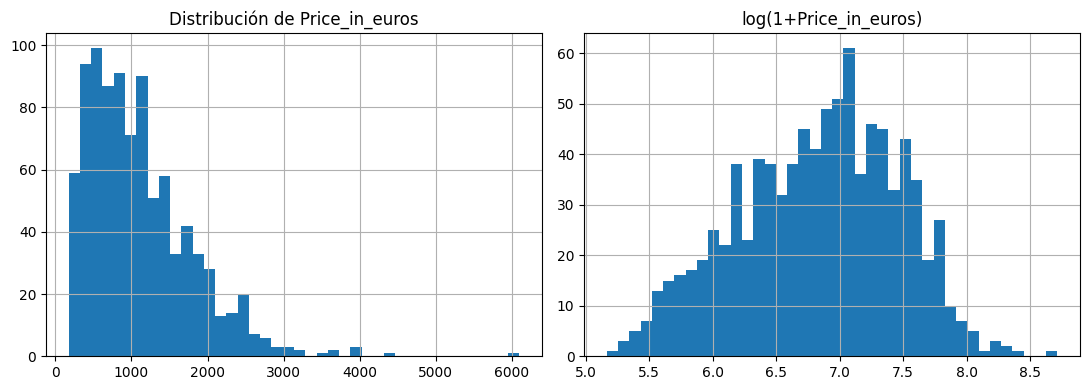

Asimetría (skew): 1.437


In [6]:
# Distribución del target.
TARGET = 'Price_in_euros'   # nombre de la columna objetivo
import matplotlib.pyplot as plt
if TARGET in df.columns:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    df[TARGET].hist(bins=40, ax=ax[0]); ax[0].set_title(f'Distribución de {TARGET}')
    np.log1p(df[TARGET]).hist(bins=40, ax=ax[1]); ax[1].set_title(f'log(1+{TARGET})')
    plt.tight_layout(); plt.show()
    print("Asimetría (skew):", round(df[TARGET].skew(), 3))

### 2.2 Definir X e y


In [7]:
# Tu código aquí
# 👉 ADAPTAR los nombres si tu dataset usa otros.
ID_COL = 'laptop_ID'   # identificador (no es predictor)
TARGET = 'Price_in_euros'       # objetivo

# columnas a excluir de X
drop_cols = [col for col in [ID_COL, TARGET] if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[TARGET]

USE_LOG_TARGET = True
y_model = np.log1p(y) if USE_LOG_TARGET else y

print("X:", X.shape, "| y:", y.shape)
print("Columnas de X:", list(X.columns))

X: (912, 11) | y: (912,)
Columnas de X: ['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']


### 2.3 Dividir en train y test

In [8]:
# Tu código aquí
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (729, 11) | Test: (183, 11)


## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [9]:
# Tu código aquí

num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()
print("Numéricas :", num_features)
print("Categóricas:", cat_features)

# Sub-pipelines de preprocesado
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore')),
])

# ColumnTransformer: aplica cada sub-pipeline a sus columnas
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, num_features),
    ('cat', categorical_pipe, cat_features),
])
print("Preprocesador construido.")

Numéricas : ['Inches']
Categóricas: ['Company', 'Product', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']
Preprocesador construido.


## 4. Modelado

### 4.1 Entrenamiento

In [10]:
# Tu código aquí

from sklearn.metrics import make_scorer
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

modelos = {
    'Ridge':            Ridge(random_state=RANDOM_STATE),
    'RandomForest':     RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE,
                                              n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'SVR':              SVR(),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados = []
pipes = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', modelo)])
    pipes[nombre] = pipe
    scores = cross_val_score(pipe, X_train, y_train, cv=kf,
                             scoring=rmse_scorer, n_jobs=-1)
    rmse_cv = -scores.mean()   # volvemos a positivo
    resultados.append({'modelo': nombre, 'RMSE_CV': rmse_cv})
    print(f"{nombre:18s} RMSE CV = {rmse_cv:.4f}")

tabla = pd.DataFrame(resultados).sort_values('RMSE_CV')
tabla

Ridge              RMSE CV = 0.2205
RandomForest       RMSE CV = 0.2487
GradientBoosting   RMSE CV = 0.2547
SVR                RMSE CV = 0.2223


,modelo,RMSE_CV
0,Ridge,0.220509
3,SVR,0.222258
1,RandomForest,0.248723
2,GradientBoosting,0.254690


### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [11]:
# Tu código aquí
mejor_nombre = tabla.iloc[0]['modelo']
mejor_pipe = pipes[mejor_nombre]
print("Mejor modelo por CV:", mejor_nombre)

# Entrenar en train y evaluar en test local
mejor_pipe.fit(X_train, y_train)
pred_test = mejor_pipe.predict(X_test)

if USE_LOG_TARGET:
    # deshacer log para medir en euros
    rmse_real = root_mean_squared_error(np.expm1(y_test), np.expm1(pred_test))
    rmse_log  = root_mean_squared_error(y_test, pred_test)
    print(f"RMSE test (escala log) : {rmse_log:.4f}")
    print(f"RMSE test (euros)      : {rmse_real:.2f}")
else:
    rmse_real = root_mean_squared_error(y_test, pred_test)
    print(f"RMSE test (euros): {rmse_real:.2f}")

Mejor modelo por CV: Ridge
RMSE test (escala log) : 0.2405
RMSE test (euros)      : 337.84


### 4.3 Optimización (up to you 🫰🏻)

In [12]:
# Tu código aquí
grids = {
    'RandomForest': {
        'model__n_estimators': [300, 600],
        'model__max_depth': [None, 15, 25],
        'model__min_samples_leaf': [1, 2, 4],
    },
    'GradientBoosting': {
        'model__n_estimators': [200, 400],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [2, 3, 4],
    },
    'Ridge':  {'model__alpha': [0.1, 1.0, 10.0, 50.0]},
    'SVR':    {'model__C': [1, 10, 100], 'model__gamma': ['scale', 'auto']},
}

if mejor_nombre in grids:
    gs = GridSearchCV(pipes[mejor_nombre], grids[mejor_nombre],
                      scoring=rmse_scorer, cv=kf, n_jobs=-1)
    gs.fit(X_train, y_train)
    print("Mejores hiperparámetros:", gs.best_params_)
    print("Mejor RMSE CV:", round(-gs.best_score_, 4))
    mejor_pipe = gs.best_estimator_   # nos quedamos con el optimizado
else:
    print("Sin grid definido para", mejor_nombre, "- se mantiene el pipeline base.")

Mejores hiperparámetros: {'model__alpha': 1.0}
Mejor RMSE CV: 0.2205


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [13]:
# Tu código aquí

modelo_final = mejor_pipe        # contiene preprocesado + modelo óptimo
modelo_final.fit(X, y_model)     # X, y_model = dataset completo de train.csv
print("Modelo final reentrenado sobre todo train.csv.")

Modelo final reentrenado sobre todo train.csv.


---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [14]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [15]:
# Tu código aquí
ids_pred = X_pred[ID_COL].copy()


X_pred_features = X_pred.drop(columns=[col for col in [ID_COL, TARGET]
                                       if col in X_pred.columns])

# columnas alineadas con las de entrenamiento (mismas y en el mismo orden)
X_pred_features = X_pred_features.reindex(columns=X.columns)
print("Columnas alineadas:", list(X_pred_features.columns) == list(X.columns))

Columnas alineadas: True


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [16]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [17]:
# Tu código aquí
# Predicción final
pred = modelo_final.predict(X_pred_features)
if USE_LOG_TARGET:
    pred = np.expm1(pred)          # volver a euros
pred = np.clip(pred, 0, None)      # un precio nunca es negativo

# Construir la submission con el formato del sample

col_id    = sample.columns[0]      
col_price = sample.columns[1]     

submission = pd.DataFrame({col_id: ids_pred.values, col_price: pred})
submission.head()

,laptop_ID,Price_in_euros
0,209,1336.607970
1,1281,287.275115
2,1168,406.066115
3,1231,1118.152469
4,1020,1058.533631


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [18]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [19]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260713_132834.csv'. ¡A Kaggle!
